# K-Means Clustering

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('/content/CC GENERAL.csv')

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
dataset.shape

(8950, 18)

In [5]:
X = dataset.iloc[:,[3,4]].values

In [6]:
print(X)

[[  95.4     0.  ]
 [   0.      0.  ]
 [ 773.17  773.17]
 ...
 [ 144.4     0.  ]
 [   0.      0.  ]
 [1093.25 1093.25]]


### Using the elbow method to find the optimal number of clusters

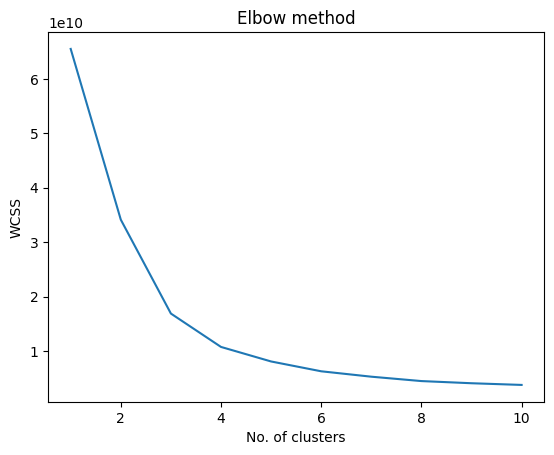

In [7]:
 from sklearn.cluster import KMeans
 wcss = []
 for i in range(1,11):
   kmeans = KMeans(n_clusters= i, init='k-means++',random_state= 42)
   kmeans.fit(X)
   wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title("Elbow method")
plt.xlabel("No. of clusters")
plt.ylabel("WCSS")
plt.show()


## Training the K-Means model on the dataset

In [8]:
kmeans = KMeans(n_clusters= 5, init='k-means++',random_state= 42)
kmeans.fit(X)

KMeans(n_clusters=5, random_state=42)

## Statistics from the initialization run with the lowest SSE are available as attributes of kmeans after calling .fit()

In [9]:
# The lowest SSE value
kmeans.inertia_

8090846076.694233

In [10]:
# Final locations of the centroid
kmeans.cluster_centers_

array([[ 1928.29316927,  1108.73142257],
       [  290.37033368,   110.10738567],
       [29682.59526316, 24341.31157895],
       [ 4794.33307175,  3276.72192825],
       [10515.5559434 ,  7472.77490566]])

In [11]:
# The number of iterations required to converge
kmeans.n_iter_

17

In [12]:
#Finally, the cluster assignments are stored as a one-dimensional NumPy array in kmeans.labels_
kmeans.labels_

array([1, 1, 1, ..., 1, 1, 0], dtype=int32)

## Creating Output labels for Generating Graph

In [13]:
y_kmeans = kmeans.fit_predict(X)

In [14]:
print(y_kmeans)

[1 1 1 ... 1 1 0]


## Visualising the clusters

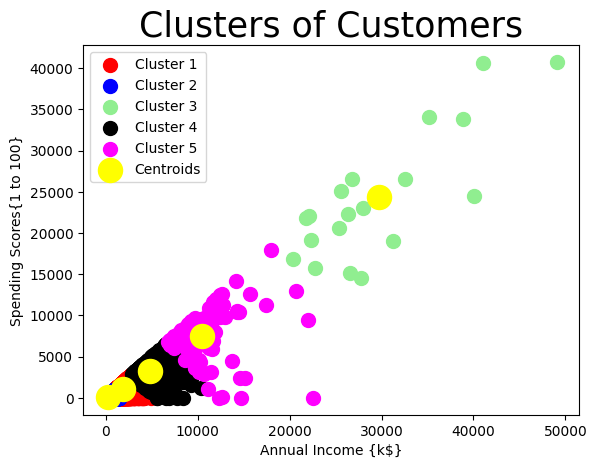

In [15]:
plt.scatter(X[y_kmeans == 0,0],X[y_kmeans == 0,1],s=100, c = 'red', label ="Cluster 1")
plt.scatter(X[y_kmeans == 1,0],X[y_kmeans == 1,1],s=100, c = 'blue', label ="Cluster 2")
plt.scatter(X[y_kmeans == 2,0],X[y_kmeans == 2,1],s=100, c = 'lightgreen', label ="Cluster 3")
plt.scatter(X[y_kmeans == 3,0],X[y_kmeans == 3,1],s=100, c = 'black', label ="Cluster 4")
plt.scatter(X[y_kmeans == 4,0],X[y_kmeans == 4,1],s=100, c = 'magenta', label ="Cluster 5")
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s = 300, c = 'Yellow',label = 'Centroids')
plt.title("Clusters of Customers",size = 25)
plt.xlabel("Annual Income {k$}")
plt.ylabel("Spending Scores{1 to 100}")
plt.legend()
plt.show()

## Internal Evaluation of Cluster
### DB Score (lower is better)

In [16]:
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(X,y_kmeans)

np.float64(0.6406530886004794)

## External Evaluation
### Homogenity Score (higher is better)

In [17]:
y_pred = kmeans.predict(X)

In [18]:
from sklearn.metrics.cluster import homogeneity_score
homogeneity_score(y_kmeans,y_pred)

np.float64(1.0)